vẽ biểu đồ dữ liệu thô và khi chuẩn hóa hóa

[[5741    0    0    0    0]
 [   0 5237    0    0    0]
 [   0    0  897    0    1]
 [   0    0    0 5467   15]
 [   0    0    8    0 3951]]


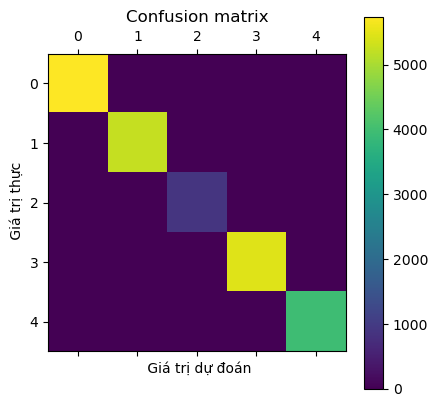

In [4]:
import numpy as np
import matplotlib.pyplot as plt

cm = np.loadtxt("/home/B2205945-CT255/ProJect_yolo/out/confusion_matrix.csv", delimiter=",").astype(int)
classes = [line.strip() for line in open("/home/B2205945-CT255/ProJect_yolo/out/classes.txt", encoding="utf-8")]

print (cm)
plt.matshow(cm)
plt.title('Confusion matrix')
plt.colorbar()
plt.ylabel(' Giá trị thực')
plt.xlabel(' Giá trị dự đoán')
plt.show()



In [5]:
# tools/evaluate_again.py
# -*- coding: utf-8 -*-
"""
Regenerate evaluation artifacts from saved files (no retraining needed).

Inputs expected (default: ./out):
  - classes.txt             # class order (one per line)
  - y_test.npy              # ground-truth labels (int-encoded)
  - y_pred.npy              # predicted labels (int-encoded)
  - test_probs.npy          # softmax probabilities (N, C)

Outputs (written to <out_dir>/eval_again/):
  - classification_report.txt / .json
  - confusion_matrix.csv / confusion_matrix.png / confusion_matrix_norm.png
  - roc_ovr.png (one-vs-rest ROC, per class + micro/macro)
  - prc_ovr.png (precision-recall curves, per class + micro/macro)
  - metrics_summary.json (accuracy, macro/weighted F1, AP, etc.)
"""

import os, json, argparse
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve, auc,
    precision_recall_curve, average_precision_score,
    accuracy_score, f1_score
)
from sklearn.preprocessing import label_binarize


def _ensure_dir(p):
    os.makedirs(p, exist_ok=True)


def _load_classes(path):
    with open(path, encoding="utf-8") as f:
        return [line.strip() for line in f if line.strip()]


def _save_cm_images(cm, classes, out_png, out_png_norm):
    # Counts
    plt.figure(figsize=(6,5))
    plt.imshow(cm, interpolation="nearest")
    plt.title("Confusion Matrix (counts)")
    plt.colorbar()
    plt.xticks(range(len(classes)), classes, rotation=45, ha="right")
    plt.yticks(range(len(classes)), classes)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(out_png, dpi=150)
    plt.close()

    # Row-normalized (%)
    with np.errstate(invalid="ignore", divide="ignore"):
        row_sums = cm.sum(axis=1, keepdims=True)
        cm_norm = np.divide(cm, row_sums, where=row_sums!=0)
    plt.figure(figsize=(6,5))
    plt.imshow(cm_norm, interpolation="nearest")
    plt.title("Confusion Matrix (row-normalized)")
    plt.colorbar()
    plt.xticks(range(len(classes)), classes, rotation=45, ha="right")
    plt.yticks(range(len(classes)), classes)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(out_png_norm, dpi=150)
    plt.close()


def _plot_roc_ovr(y_true, probs, classes, out_png):
    """One-vs-Rest ROC; also micro/macro."""
    n_classes = len(classes)
    y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))

    # Compute per-class ROC/AUC
    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Micro-average
    fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), probs.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    # Macro-average
    # Interpolate mean TPR over all FPR
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= n_classes
    roc_auc["macro"] = auc(all_fpr, mean_tpr)

    plt.figure(figsize=(7,6))
    # Plot per-class (limit to top-6 by AUC if many classes to keep chart readable)
    idx_sorted = sorted(range(n_classes), key=lambda i: roc_auc[i], reverse=True)
    to_show = idx_sorted if n_classes <= 6 else idx_sorted[:6]
    for i in to_show:
        plt.plot(fpr[i], tpr[i], lw=1.5, label=f"{classes[i]} (AUC={roc_auc[i]:.3f})")
    # micro & macro
    plt.plot(fpr["micro"], tpr["micro"], lw=2, linestyle="--", label=f"micro (AUC={roc_auc['micro']:.3f})")
    plt.plot(all_fpr,  mean_tpr,  lw=2, linestyle=":",  label=f"macro (AUC={roc_auc['macro']:.3f})")

    plt.plot([0,1], [0,1], lw=1, linestyle="--")
    plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("One-vs-Rest ROC")
    plt.legend(loc="lower right", fontsize=8)
    plt.tight_layout()
    plt.savefig(out_png, dpi=150)
    plt.close()

    # Return AUC dict for summary
    return {("class_" + classes[i]): float(roc_auc[i]) for i in range(n_classes)} | {
        "micro": float(roc_auc["micro"]), "macro": float(roc_auc["macro"])
    }


def _plot_prc_ovr(y_true, probs, classes, out_png):
    """One-vs-Rest Precision-Recall; also micro/macro AP."""
    n_classes = len(classes)
    y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))

    prc_ap = {}
    plt.figure(figsize=(7,6))
    # per-class
    aps = []
    idx_all = list(range(n_classes))
    # Limit to top-6 by AP if many classes
    tmp_ap = []
    for i in idx_all:
        precision, recall, _ = precision_recall_curve(y_true_bin[:, i], probs[:, i])
        ap = average_precision_score(y_true_bin[:, i], probs[:, i])
        tmp_ap.append((i, precision, recall, ap))
    tmp_ap.sort(key=lambda t: t[3], reverse=True)
    to_show = tmp_ap if n_classes <= 6 else tmp_ap[:6]
    for i, precision, recall, ap in to_show:
        plt.plot(recall, precision, lw=1.5, label=f"{classes[i]} (AP={ap:.3f})")
        prc_ap["class_" + classes[i]] = float(ap)

    # micro-average (treat every (sample,class) as binary)
    precision_micro, recall_micro, _ = precision_recall_curve(y_true_bin.ravel(), probs.ravel())
    ap_micro = average_precision_score(y_true_bin, probs, average="micro")
    plt.plot(recall_micro, precision_micro, lw=2, linestyle="--", label=f"micro (AP={ap_micro:.3f})")

    plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("One-vs-Rest Precision–Recall")
    plt.legend(loc="lower left", fontsize=8)
    plt.tight_layout()
    plt.savefig(out_png, dpi=150)
    plt.close()

    prc_ap["micro"] = float(ap_micro)
    # macro AP (mean over classes)
    prc_ap["macro"] = float(np.mean([t[3] for t in tmp_ap]))
    return prc_ap


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--out_dir", type=str, default="out", help="Directory containing saved artifacts.")
    args = parser.parse_args()

    out_dir = args.out_dir
    eval_dir = os.path.join(out_dir, "eval_again")
    _ensure_dir(eval_dir)

    # ---- Load artifacts
    paths = {
        "classes": os.path.join(out_dir, "classes.txt"),
        "y_test":  os.path.join(out_dir, "y_test.npy"),
        "y_pred":  os.path.join(out_dir, "y_pred.npy"),
        "probs":   os.path.join(out_dir, "test_probs.npy"),
    }
    for k, p in paths.items():
        if not os.path.isfile(p):
            raise FileNotFoundError(f"Missing file: {p}")

    classes = _load_classes(paths["classes"])
    y_test = np.load(paths["y_test"])
    y_pred = np.load(paths["y_pred"])
    probs  = np.load(paths["probs"])

    n_classes = len(classes)
    assert probs.shape[1] == n_classes, "test_probs col != num classes"
    assert y_test.shape[0] == probs.shape[0] == y_pred.shape[0], "Mismatched N"

    # ---- Classification report
    report_txt = classification_report(y_test, y_pred, target_names=classes, digits=4)
    report_dict = classification_report(y_test, y_pred, target_names=classes, digits=4, output_dict=True)

    with open(os.path.join(eval_dir, "classification_report.txt"), "w", encoding="utf-8") as f:
        f.write(report_txt)
    with open(os.path.join(eval_dir, "classification_report.json"), "w", encoding="utf-8") as f:
        json.dump(report_dict, f, ensure_ascii=False, indent=2)

    # ---- Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    np.savetxt(os.path.join(eval_dir, "confusion_matrix.csv"), cm, fmt="%d", delimiter=",")
    _save_cm_images(
        cm, classes,
        out_png=os.path.join(eval_dir, "confusion_matrix.png"),
        out_png_norm=os.path.join(eval_dir, "confusion_matrix_norm.png")
    )

    # ---- ROC (OvR) & PRC (OvR)
    aucs = _plot_roc_ovr(y_test, probs, classes, os.path.join(eval_dir, "roc_ovr.png"))
    aps  = _plot_prc_ovr(y_test, probs, classes, os.path.join(eval_dir, "prc_ovr.png"))

    # ---- Summary metrics
    summary = {
        "accuracy": float(accuracy_score(y_test, y_pred)),
        "f1_macro": float(f1_score(y_test, y_pred, average="macro")),
        "f1_weighted": float(f1_score(y_test, y_pred, average="weighted")),
        "roc_auc": aucs,       # per-class + micro/macro
        "avg_precision": aps,  # per-class + micro/macro
        "n_samples": int(len(y_test)),
        "n_classes": int(n_classes),
        "classes": classes,
    }
    with open(os.path.join(eval_dir, "metrics_summary.json"), "w", encoding="utf-8") as f:
        json.dump(summary, f, ensure_ascii=False, indent=2)

    print("✅ Re-generated evaluation artifacts in:", eval_dir)
    print("- classification_report.txt / .json")
    print("- confusion_matrix.csv / .png / _norm.png")
    print("- roc_ovr.png, prc_ovr.png")
    print("- metrics_summary.json")


if __name__ == "__main__":
    main()


ModuleNotFoundError: No module named 'sklearn'